In [1]:
# Pakistan Unemployment Analysis Dashboard
## Task 2 - Data Visualization
### Source: Pakistan Bureau of Statistics (PBS)

In [2]:
!pip install plotly scikit-learn pandas numpy

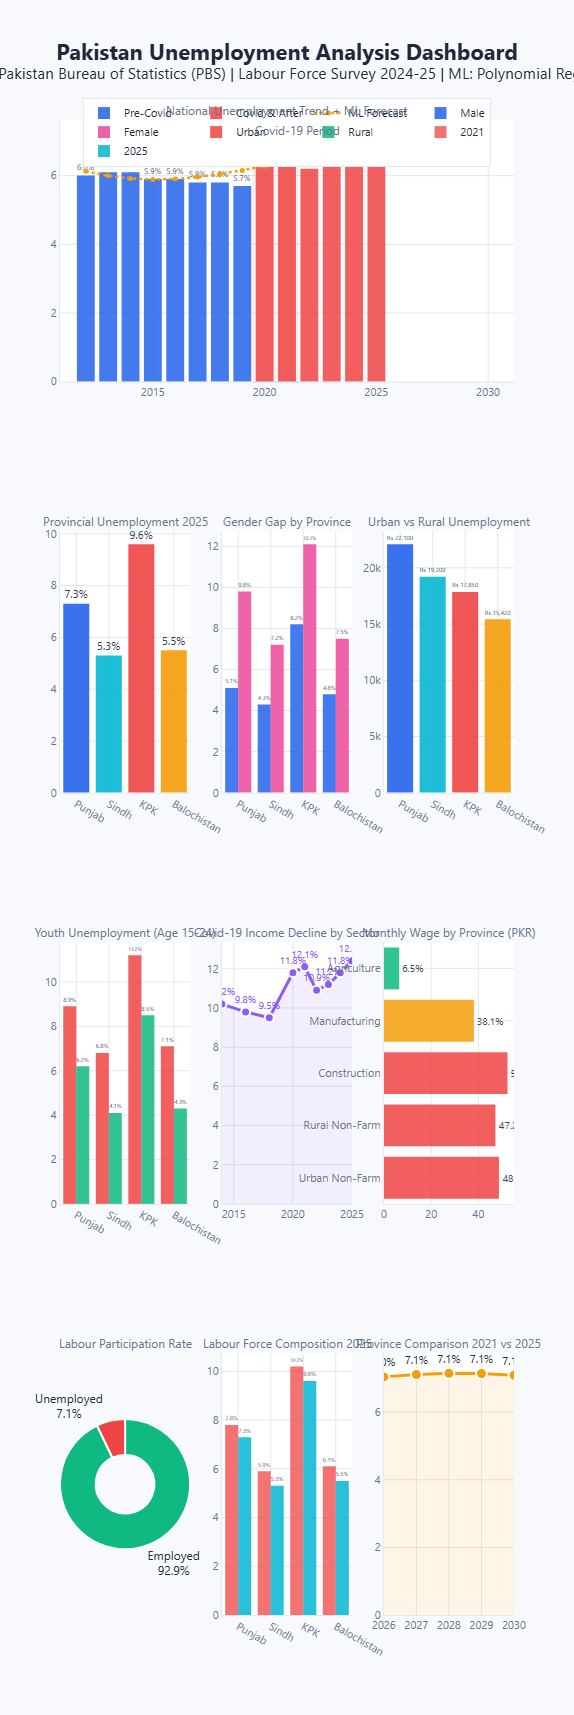


  MACHINE LEARNING FORECAST  (Polynomial Regression)
  2026  ->  Predicted Rate : 7.04%
  2027  ->  Predicted Rate : 7.11%
  2028  ->  Predicted Rate : 7.15%
  2029  ->  Predicted Rate : 7.14%
  2030  ->  Predicted Rate : 7.09%

  KEY FINDINGS
  - National rate 7.1% in 2025  —  highest since 2003
  - KPK highest unemployment at 9.6%
  - Female unemployment 8.9%  vs  Male 5.6%
  - Youth unemployment 12.4%  —  double national average
  - Construction hardest hit by Covid  (52.3% income drop)
  - Agriculture least affected  (only 6.5% income decline)
  - Punjab highest avg monthly wage  Rs 22,100
  - 6 million jobs lost during Covid lockdown 2020


In [3]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# DATA
# ============================================================
years = np.array([2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025])
national_unemp = np.array([6.0,6.1,6.1,5.9,5.9,5.8,5.8,5.7,6.9,7.1,6.2,6.3,6.8,7.1])

provinces    = ['Punjab','Sindh','KPK','Balochistan']
prov_2021    = [7.8, 5.9, 10.2, 6.1]
prov_2025    = [7.3, 5.3,  9.6, 5.5]
male_unemp   = [5.1, 4.3,  8.2, 4.8]
female_unemp = [9.8, 7.2, 12.1, 7.5]
urban_unemp  = [8.9, 6.8, 11.2, 7.1]
rural_unemp  = [6.2, 4.1,  8.5, 4.3]

youth_years = [2014,2016,2018,2020,2021,2022,2023,2024,2025]
youth_unemp = [10.2,9.8,9.5,11.8,12.1,10.9,11.2,11.8,12.4]

sectors      = ['Urban Non-Farm','Rural Non-Farm','Construction','Manufacturing','Agriculture']
covid_impact = [48.7, 47.2, 52.3, 38.1, 6.5]

wages = [22100, 19200, 17850, 15420]
lpr   = [46.2,  35.1,  20.3, 45.8]

# ============================================================
# ML FORECAST
# ============================================================
poly  = PolynomialFeatures(degree=3)
X_p   = poly.fit_transform(years.reshape(-1,1))
model = LinearRegression().fit(X_p, national_unemp)

future_years = np.array([2026,2027,2028,2029,2030])
all_years    = np.concatenate([years, future_years])
predicted    = np.clip(model.predict(poly.transform(all_years.reshape(-1,1))), 4, 12)

# ============================================================
# COLOURS
# ============================================================
C_BG     = '#F7F9FC'
C_PANEL  = '#FFFFFF'
C_BORDER = '#E2E8F0'
C_TEXT   = '#1E293B'
C_MUTED  = '#64748B'
C_BLUE   = '#2563EB'
C_RED    = '#EF4444'
C_GREEN  = '#10B981'
C_AMBER  = '#F59E0B'
C_PURPLE = '#8B5CF6'
C_TEAL   = '#06B6D4'
C_PINK   = '#EC4899'
PROV_CLR = [C_BLUE, C_TEAL, C_RED, C_AMBER]

# ============================================================
# SUBPLOT GRID
# ============================================================
fig = make_subplots(
    rows=4, cols=3,
    subplot_titles=[
        'National Unemployment Trend + ML Forecast',
        'Provincial Unemployment 2025',
        'Gender Gap by Province',
        'Urban vs Rural Unemployment',
        'Youth Unemployment (Age 15-24)',
        'Covid-19 Income Decline by Sector',
        'Monthly Wage by Province (PKR)',
        'Labour Participation Rate',
        'Labour Force Composition 2025',
        'Province Comparison 2021 vs 2025',
        'ML Forecast 2026-2030',
        '',
    ],
    specs=[
        [{"colspan": 3, "type": "xy"},   None,           None          ],
        [{"type": "xy"},                 {"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"},                 {"type": "xy"}, {"type": "xy"}],
        [{"type": "domain"},             {"type": "xy"}, {"type": "xy"}],
    ],
    vertical_spacing=0.10,
    horizontal_spacing=0.07,
)

# ============================================================
# ROW 1 — National Trend + ML Forecast
# ============================================================
mask_pre  = years < 2020
mask_post = years >= 2020

fig.add_trace(go.Bar(
    x=years[mask_pre], y=national_unemp[mask_pre],
    name='Pre-Covid', marker_color=C_BLUE,
    marker_line_width=0, opacity=0.85,
    text=[f'{v}%' for v in national_unemp[mask_pre]],
    textposition='outside',
    textfont=dict(size=10, color=C_TEXT),
), row=1, col=1)

fig.add_trace(go.Bar(
    x=years[mask_post], y=national_unemp[mask_post],
    name='Covid & After', marker_color=C_RED,
    marker_line_width=0, opacity=0.85,
    text=[f'{v}%' for v in national_unemp[mask_post]],
    textposition='outside',
    textfont=dict(size=10, color=C_TEXT),
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=all_years, y=predicted,
    mode='lines+markers', name='ML Forecast',
    line=dict(color=C_AMBER, width=2.5, dash='dot'),
    marker=dict(size=5, color=C_AMBER),
), row=1, col=1)

fig.add_vrect(
    x0=2019.5, x1=2021.5,
    fillcolor=C_RED, opacity=0.07,
    annotation_text='Covid-19 Period',
    annotation_font=dict(color=C_RED, size=11),
    annotation_position='top left',
    row=1, col=1,
)

# ============================================================
# ROW 2
# ============================================================

# Provincial 2025
fig.add_trace(go.Bar(
    x=provinces, y=prov_2025,
    marker_color=PROV_CLR,
    marker_line_width=0, opacity=0.9,
    text=[f'{v}%' for v in prov_2025],
    textposition='outside',
    textfont=dict(size=11, color=C_TEXT),
    name='2025 Rate', showlegend=False,
), row=2, col=1)

# Gender Gap
fig.add_trace(go.Bar(
    x=provinces, y=male_unemp,
    name='Male', marker_color=C_BLUE,
    marker_line_width=0, opacity=0.85,
    text=[f'{v}%' for v in male_unemp],
    textposition='outside',
    textfont=dict(size=10, color=C_TEXT),
), row=2, col=2)

fig.add_trace(go.Bar(
    x=provinces, y=female_unemp,
    name='Female', marker_color=C_PINK,
    marker_line_width=0, opacity=0.85,
    text=[f'{v}%' for v in female_unemp],
    textposition='outside',
    textfont=dict(size=10, color=C_TEXT),
), row=2, col=2)

# Wages
fig.add_trace(go.Bar(
    x=provinces, y=wages,
    marker_color=PROV_CLR,
    marker_line_width=0, opacity=0.9,
    text=[f'Rs {v:,}' for v in wages],
    textposition='outside',
    textfont=dict(size=10, color=C_TEXT),
    name='Wages', showlegend=False,
), row=2, col=3)

# ============================================================
# ROW 3
# ============================================================

# Urban vs Rural
fig.add_trace(go.Bar(
    x=provinces, y=urban_unemp,
    name='Urban', marker_color=C_RED,
    marker_line_width=0, opacity=0.85,
    text=[f'{v}%' for v in urban_unemp],
    textposition='outside',
    textfont=dict(size=10, color=C_TEXT),
), row=3, col=1)

fig.add_trace(go.Bar(
    x=provinces, y=rural_unemp,
    name='Rural', marker_color=C_GREEN,
    marker_line_width=0, opacity=0.85,
    text=[f'{v}%' for v in rural_unemp],
    textposition='outside',
    textfont=dict(size=10, color=C_TEXT),
), row=3, col=1)

# Youth Unemployment (FIXED - no duplicate mode)
fig.add_trace(go.Scatter(
    x=youth_years, y=youth_unemp,
    mode='lines+markers+text',
    line=dict(color=C_PURPLE, width=3),
    marker=dict(size=9, color=C_PURPLE,
                line=dict(color='white', width=2)),
    fill='tozeroy',
    fillcolor='rgba(139,92,246,0.10)',
    name='Youth Unemp', showlegend=False,
    text=[f'{v}%' for v in youth_unemp],
    textposition='top center',
    textfont=dict(size=10, color=C_PURPLE),
), row=3, col=2)

# Covid Sectoral
fig.add_trace(go.Bar(
    x=covid_impact, y=sectors,
    orientation='h',
    marker_color=[C_RED, C_RED, C_RED, C_AMBER, C_GREEN],
    marker_line_width=0, opacity=0.85,
    text=[f'{v}%' for v in covid_impact],
    textposition='outside',
    textfont=dict(size=10, color=C_TEXT),
    name='Income Drop', showlegend=False,
), row=3, col=3)

# ============================================================
# ROW 4
# ============================================================

# Pie Chart
fig.add_trace(go.Pie(
    labels=['Employed', 'Unemployed'],
    values=[92.9, 7.1],
    marker=dict(
        colors=[C_GREEN, C_RED],
        line=dict(color='white', width=2)
    ),
    textinfo='label+percent',
    textfont=dict(size=12, color=C_TEXT),
    hole=0.45,
    name='Composition',
    showlegend=False,
), row=4, col=1)

# Province 2021 vs 2025
fig.add_trace(go.Bar(
    x=provinces, y=prov_2021,
    name='2021', marker_color=C_RED,
    marker_line_width=0, opacity=0.75,
    text=[f'{v}%' for v in prov_2021],
    textposition='outside',
    textfont=dict(size=10, color=C_TEXT),
), row=4, col=2)

fig.add_trace(go.Bar(
    x=provinces, y=prov_2025,
    name='2025', marker_color=C_TEAL,
    marker_line_width=0, opacity=0.85,
    text=[f'{v}%' for v in prov_2025],
    textposition='outside',
    textfont=dict(size=10, color=C_TEXT),
), row=4, col=2)

# ML Forecast Line
fig.add_trace(go.Scatter(
    x=list(future_years),
    y=list(predicted[-5:]),
    mode='lines+markers+text',
    line=dict(color=C_AMBER, width=3),
    marker=dict(size=11, color=C_AMBER,
                line=dict(color='white', width=2)),
    text=[f'{v:.1f}%' for v in predicted[-5:]],
    textposition='top center',
    textfont=dict(size=11, color=C_TEXT),
    name='Forecast', showlegend=False,
    fill='tozeroy',
    fillcolor='rgba(245,158,11,0.10)',
), row=4, col=3)

# ============================================================
# LAYOUT
# ============================================================
fig.update_layout(
    height=1700,
    width=1400,
    paper_bgcolor=C_BG,
    plot_bgcolor=C_PANEL,
    font=dict(family='Segoe UI, Arial', color=C_TEXT, size=12),
    barmode='group',
    title=dict(
        text='<b>Pakistan Unemployment Analysis Dashboard</b><br><sup>Source: Pakistan Bureau of Statistics (PBS) | Labour Force Survey 2024-25 | ML: Polynomial Regression</sup>',
        x=0.5, xanchor='center',
        font=dict(size=22, color=C_TEXT),
        pad=dict(b=20),
    ),
    legend=dict(
        bgcolor=C_PANEL,
        bordercolor=C_BORDER,
        borderwidth=1,
        font=dict(color=C_TEXT, size=11),
        orientation='h',
        x=0.5, xanchor='center', y=1.015,
    ),
    margin=dict(t=120, b=60, l=60, r=60),
)

# Clean axis style
axis_cfg = dict(
    showgrid=True, gridcolor=C_BORDER, gridwidth=1,
    zeroline=False, linecolor=C_BORDER,
    tickfont=dict(color=C_MUTED, size=11),
    title_font=dict(color=C_MUTED, size=11),
)

for r in range(1, 5):
    for c in range(1, 4):
        try:
            fig.update_xaxes(axis_cfg, row=r, col=c)
            fig.update_yaxes(axis_cfg, row=r, col=c)
        except Exception:
            pass

# Subplot title font
for ann in fig.layout.annotations:
    ann.font = dict(size=12, color=C_MUTED, family='Segoe UI, Arial')

fig.show()

# ============================================================
# PRINT RESULTS
# ============================================================
print("\n" + "="*60)
print("  MACHINE LEARNING FORECAST  (Polynomial Regression)")
print("="*60)
for yr, pred in zip(future_years, predicted[-5:]):
    print(f"  {yr}  ->  Predicted Rate : {pred:.2f}%")

print("\n" + "="*60)
print("  KEY FINDINGS")
print("="*60)
findings = [
    "National rate 7.1% in 2025  —  highest since 2003",
    "KPK highest unemployment at 9.6%",
    "Female unemployment 8.9%  vs  Male 5.6%",
    "Youth unemployment 12.4%  —  double national average",
    "Construction hardest hit by Covid  (52.3% income drop)",
    "Agriculture least affected  (only 6.5% income decline)",
    "Punjab highest avg monthly wage  Rs 22,100",
    "6 million jobs lost during Covid lockdown 2020",
]
for f in findings:
    print(f"  - {f}")
print("="*60)